# Régression logistique

1.   Application d’une AFDM pour résumer la variabilité génétique et métabolique des souches.
2.   Application d’une régression logistique sur les 20 premiers composantes pour d’identifier les dimensions les plus associées à la présence d’un halo antibactérien.

### Packages necessaires

In [1]:
#!pip install prince

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import prince
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
import seaborn as sns
import plotly.graph_objects as go

### Exploration et traitement des données

In [3]:
df = pd.read_csv("../data/sortie/dataset_complet_sans_auto_inhibition.csv")

# Suppression des NA
df_clean = df.dropna()

print(f"Lignes avant nettoyage : {len(df)}")
print(f"Lignes après nettoyage : {len(df_clean)}")
print(f"Lignes supprimées : {len(df) - len(df_clean)}")


Lignes avant nettoyage : 1259
Lignes après nettoyage : 964
Lignes supprimées : 295


In [4]:
# Compter le nombre de souches productrices et cibles
nb_productrice = df_clean['productrice'].nunique()
nb_cible = df_clean['cible'].nunique()

print(f"Nombre de productrices distinctes : {nb_productrice}")
print(f"Nombre de cibles distinctes : {nb_cible}")

Nombre de productrices distinctes : 34
Nombre de cibles distinctes : 34


In [5]:
# Définition de la variable cible
y = df_clean["halo"].astype(int)

# Suppression des colonnes inutiles
X = df_clean.drop(columns=["halo", "cible", "productrice", "couple", "Souche_P", "Souche_C"], errors="ignore")

# Suppression des gènes hypothétiques
X = X[[c for c in X.columns if "hypothetical" not in c.lower()]]

# Nombre des variables et observations
nb_obs, nb_total = X.shape

binaires = [c for c in X.columns if set(X[c].dropna().unique()) <= {0, 1}]
nb_binaires = len(binaires)
nb_non_binaires = nb_total - nb_binaires

print(f"Nombre d'observations : {nb_obs}")
print(f"Nombre de variables   : {nb_total}")
print(f"Nombre de variables binaires (gènes) : {nb_binaires}")
print(f"Nombre de variables non binaires (pics): {nb_non_binaires}")

Nombre d'observations : 964
Nombre de variables   : 9584
Nombre de variables binaires (gènes) : 740
Nombre de variables non binaires (pics): 8844


In [6]:
# Vérification de la variabilité des gènes
variabilite = X[binaires].nunique()
genes_constants = variabilite[variabilite == 1].index.tolist()
genes_variables = variabilite[variabilite > 1].index.tolist()

print(f"Nombre de gènes constants (pas de variabilité) : {len(genes_constants)}")
print(f"Nombre de gènes variables : {len(genes_variables)}")

Nombre de gènes constants (pas de variabilité) : 226
Nombre de gènes variables : 514


In [7]:
# Vérifions dans la liste des gènes constants, ceux des cibles et productrices
genes_constants_P = [g for g in genes_constants if g.endswith('_P')]
genes_constants_C = [g for g in genes_constants if g.endswith('_C')]

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - dont gènes productrices (_P) : {len(genes_constants_P)}")
print(f" - dont gènes cibles (_C)       : {len(genes_constants_C)}")

Nombre total de gènes constants : 226
 - dont gènes productrices (_P) : 113
 - dont gènes cibles (_C)       : 113


In [8]:
# Vérifions la valeur constante (0 ou 1) des gènes
valeurs_constants = {g: df[g].unique()[0] for g in genes_constants}

# Comptage des gènes constants à 0 et à 1
nb_constants_0 = sum(v == 0 for v in valeurs_constants.values())
nb_constants_1 = sum(v == 1 for v in valeurs_constants.values())

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - constants à 0 : {nb_constants_0}")
print(f" - constants à 1 : {nb_constants_1}")

Nombre total de gènes constants : 226
 - constants à 0 : 226
 - constants à 1 : 0


In [9]:
# Suppression des gènes constants
X = X.drop(columns=genes_constants)

In [10]:
nb_obs, nb_total = X.shape

# Colonnes binaires (gènes)
binaires = [c for c in X.columns if set(X[c].dropna().unique()) <= {0, 1}]
nb_binaires = len(binaires)

# Colonnes non binaires (Profils LC-MS)
non_binaires = [c for c in X.columns if c not in binaires]
nb_non_binaires = len(non_binaires)

# Résumé
print(f"Total gènes : {nb_binaires}")
print(f"Total pics : {nb_non_binaires}")
print(f"Shape finale : {X.shape}")

Total gènes : 514
Total pics : 8844
Shape finale : (964, 9358)


In [11]:
# Conversion des variables binaires en qualitatives pour l'AFDM
X_converted = X.copy()

# Convertir en 'object' (ou 'category') pour que FAMD les traite comme qualitatives
for col in binaires:
    X_converted[col] = X_converted[col].astype('category')

# Vérification
print(X_converted[binaires].dtypes.head())

ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein_P     category
ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein_P       category
ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein_P                   category
ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor_P      category
ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_P    category
dtype: object


In [12]:
X_converted.head()

,ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein_P,ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein_P,ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein_P,ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor_P,ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_P,ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin_P,ENA.AAC16352.AAC16352.1 Escherichia coli microcin V immunity protein_P,ENA.AAC16353.AAC16353.1 Escherichia coli microcin V bacteriocin_P,ENA.AAC73892.AAC73892.1 Escherichia coli str. K-12 substr. MG1655 iron catecholate outer membrane transporter Fiu_P,ENA.AAD28494.AAD28494.1 Escherichia coli microcin J25 precursor_P,...,FT4414_C,FT4415_C,FT4416_C,FT4417_C,FT4418_C,FT4419_C,FT4420_C,FT4421_C,FT4422_C,FT4423_C
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178
6,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,50380.138106,109476.295793,106169.363789,223715.164565,113164.745644,236652.3636,64709.813273,65005.198759,60085.419043,64179.39178


### Distribution de la variable cible Y

      Fréquence  Pourcentage
halo                        
0           781        81.02
1           183        18.98


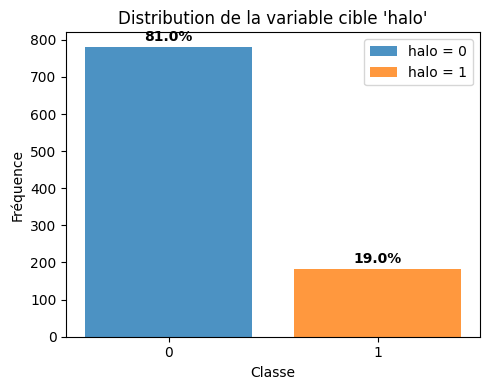

In [13]:
freq = y.value_counts().sort_index()
pct = y.value_counts(normalize=True).sort_index() * 100

resume = pd.DataFrame({"Fréquence": freq, "Pourcentage": pct.round(2)})
print(resume)

# Graphique
colors = ["#1f77b4", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(5,4))

# On trace barre par barre avec légende personnalisée
for i, (classe, valeur) in enumerate(freq.items()):
    ax.bar(i, valeur, color=colors[i], alpha=0.8, label=f"halo = {classe}")
    ax.text(i, valeur + max(freq)*0.01, f"{pct.iloc[i]:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Distribution de la variable cible 'halo'")
ax.set_xlabel("Classe")
ax.set_ylabel("Fréquence")
ax.legend(title=None)

plt.xticks(range(len(freq)), freq.index)
plt.tight_layout()
plt.show()

### Application de l'AFDM

In [14]:
# AFDM
afdm = prince.FAMD(
    n_components=len(X_converted.columns) - 1,   # maximum possible
    n_iter=5,
    random_state=42
)
afdm = afdm.fit(X_converted)

/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/prince/famd.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eta2[col] = (
/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/prince/famd.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eta2[col] = (
/home/stevensia/Documents/sam2/sam2/lib/python3.10/site-packages/prince/famd.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

In [15]:
# Récupération de la variance expliquée (inertie) pour chaque axe
eigenvalues = afdm.eigenvalues_  # valeurs propres des axes factoriels
total = sum(eigenvalues)
var_par_axe = [(eig / total) * 100 for eig in eigenvalues]
var_cum = np.cumsum(var_par_axe)

print(f"{'Axe':>5} {'Part de variance (%)':>25} {'Variance cumulée (%)':>25}")
print("-" * 60)

for i, (v_part, v_cum) in enumerate(zip(var_par_axe[:50], var_cum[:50]), start=1):
    print(f"{i:5d} {v_part:25.4f} {v_cum :25.4f}")

  Axe      Part de variance (%)      Variance cumulée (%)
------------------------------------------------------------
    1                   16.6501                   16.6501
    2                   16.1475                   32.7976
    3                   10.3037                   43.1013
    4                    9.7781                   52.8795
    5                    3.6900                   56.5694
    6                    3.3229                   59.8924
    7                    2.9478                   62.8402
    8                    2.5073                   65.3475
    9                    2.1297                   67.4771
   10                    1.9401                   69.4172
   11                    1.8843                   71.3014
   12                    1.8051                   73.1065
   13                    1.7286                   74.8351
   14                    1.6182                   76.4533
   15                    1.5111                   77.9645
   16      

In [16]:
# Coordonnées factorielles des individus sur les 20 premiers axes
coord_indiv = afdm.row_coordinates(X_converted)

# Sélection des 20 premiers axes
X_afdm_20 = coord_indiv.iloc[:, :20]

### Régression logistique avec Statsmodels

In [17]:
# On vérifie que y est bien aligné avec les nouveaux features
print((X_afdm_20.index == y.index).all())

True


In [18]:
# Définition des variables
X_logit = sm.add_constant(X_afdm_20)  # ajoute une constante pour l'intercept
y_logit = y.astype(int)

# Ajustement du modèle Logit
model = sm.Logit(y_logit, X_logit)
res = model.fit(disp=False)

# Résumé des résultats
print(res.summary())

# Extraction des coefficients sous forme de DataFrame
res_df = pd.DataFrame({
    "Variable": X_logit.columns,
    "Coef": res.params,
    "P>|z|": res.pvalues,
    "IC_inf": res.conf_int()[0],
    "IC_sup": res.conf_int()[1]
})
print("\nCoefficients :")
print(res_df.head(10))

# Prédictions et métriques
y_pred_prob = res.predict(X_logit)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n Évaluation")
print("Accuracy :", accuracy_score(y_logit, y_pred))
print("F1-score :", f1_score(y_logit, y_pred))
print("AUC ROC  :", roc_auc_score(y_logit, y_pred_prob))
print("Average Precision :", average_precision_score(y_logit, y_pred_prob))

                           Logit Regression Results                           
Dep. Variable:                   halo   No. Observations:                  964
Model:                          Logit   Df Residuals:                      943
Method:                           MLE   Df Model:                           20
Date:                Fri, 07 Nov 2025   Pseudo R-squ.:                  0.6118
Time:                        14:25:08   Log-Likelihood:                -181.85
converged:                       True   LL-Null:                       -468.49
Covariance Type:            nonrobust   LLR p-value:                1.216e-108
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3234      0.613     -7.048      0.000      -5.526      -3.121
0             -0.0001      0.001     -0.140      0.889      -0.002       0.002
1              0.0039      0.001      2.944      0.0

In [19]:
# Tri par importance absolue des variables discriminantes de la RL
coef_sorted = res_df.sort_values(by="Coef", key=lambda x: abs(x), ascending=False)
print(coef_sorted[["Variable", "Coef", "P>|z|"]].head(10))

      Variable      Coef         P>|z|
const    const -4.323447  1.810726e-12
8            8 -0.036405  5.491721e-13
11          11  0.032071  4.222689e-02
15          15  0.030504  9.605889e-14
18          18  0.027703  3.030437e-08
4            4 -0.026912  2.515183e-03
16          16  0.026022  3.190186e-08
19          19 -0.025364  1.305254e-06
6            6 -0.025008  6.768192e-02
17          17 -0.024199  1.828172e-04


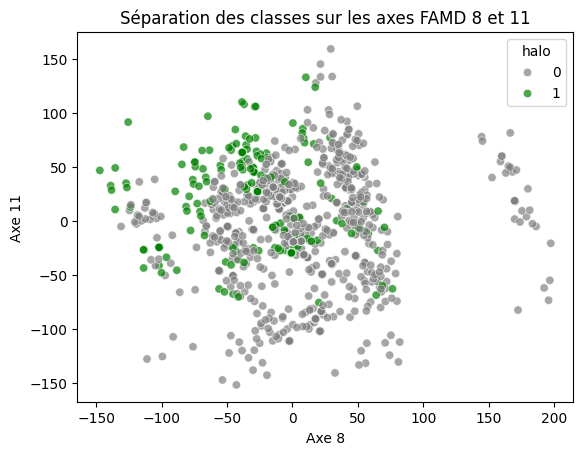

In [20]:
# Choix des deux axes les plus discriminants d'après la régression
top_axes = coef_sorted["Variable"].iloc[1:3].tolist()
sns.scatterplot(
    x=X_afdm_20[int(top_axes[0])],
    y=X_afdm_20[int(top_axes[1])],
    hue=y, palette=["gray", "green"], alpha=0.7
)
plt.title(f"Séparation des classes sur les axes FAMD {top_axes[0]} et {top_axes[1]}")
plt.xlabel(f"Axe {top_axes[0]}")
plt.ylabel(f"Axe {top_axes[1]}")
plt.show()

In [21]:
# Sélection des 3 axes les plus discriminants selon le modèle logit
coef_sorted = res_df[res_df["Variable"] != "const"].copy()
coef_sorted["abs_coef"] = coef_sorted["Coef"].abs()
top3_axes = (
    coef_sorted.sort_values("abs_coef", ascending=False)["Variable"]
    .astype(int)
    .head(3)
    .tolist()
)
print(f"Axes FAMD les plus discriminants pour la 3D : {top3_axes}")

# Préparation des données
X3D = X_afdm_20[top3_axes]
y_halo = pd.to_numeric(y, errors="coerce").fillna(0).astype(int)

# Création du scatter 3D interactif
fig = go.Figure()

# Classe 0 (gris)
fig.add_trace(go.Scatter3d(
    x=X3D[y_halo == 0].iloc[:, 0],
    y=X3D[y_halo == 0].iloc[:, 1],
    z=X3D[y_halo == 0].iloc[:, 2],
    mode='markers',
    name='halo = 0',
    marker=dict(size=4, color='lightgray', opacity=0.7)
))

# Classe 1 (vert)
fig.add_trace(go.Scatter3d(
    x=X3D[y_halo == 1].iloc[:, 0],
    y=X3D[y_halo == 1].iloc[:, 1],
    z=X3D[y_halo == 1].iloc[:, 2],
    mode='markers',
    name='halo = 1',
    marker=dict(size=5, color='green', opacity=0.85)
))

# Mise en forme du graphique

fig.update_layout(
    title=f"Séparation des classes halo sur les axes FAMD {top3_axes}",
    scene=dict(
        xaxis_title=f"Axe {top3_axes[0]}",
        yaxis_title=f"Axe {top3_axes[1]}",
        zaxis_title=f"Axe {top3_axes[2]}",
        bgcolor='rgba(0,0,0,0)'  # fond transparent
    ),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Affichage interactif
fig.show()

Axes FAMD les plus discriminants pour la 3D : [8, 11, 15]


In [22]:
# Extraction de la variance pour les axes 8 et 11 (Python est 0-based)
var_dim8 = var_par_axe[7]   # Axe 8 → index 7
var_dim11 = var_par_axe[10] # Axe 11 → index 10
#var_dim15 = var_par_axe[14] # Axe 15 → index 14

# Somme totale
var_tot = var_dim8 + var_dim11 #+ var_dim15

print(f"Variance expliquée par Dim.8 : {var_dim8:.2f} %")
print(f"Variance expliquée par Dim.11 : {var_dim11:.2f} %")
#print(f"Variance expliquée par Dim.15 : {var_dim15:.2f} %")
print(f"Variance cumulée expliquée par Dim.8 et Dim.11 : {var_tot:.2f} %")

Variance expliquée par Dim.8 : 2.51 %
Variance expliquée par Dim.11 : 1.88 %
Variance cumulée expliquée par Dim.8 et Dim.11 : 4.39 %


In [23]:
axes_cibles = [8, 11, 15]   # axes à interpréter
coord = X_afdm_20.iloc[:, :20]  # coordonnées factorielles (20 axes)
X_converted = X_converted.apply(pd.to_numeric, errors='ignore')

# Identification des variables quantitatives et qualitatives
quant_vars = X_converted.select_dtypes(include=[np.number]).columns
qual_vars = X_converted.select_dtypes(exclude=[np.number]).columns

# Matrice pour les corrélations
correlations = pd.DataFrame(index=X_converted.columns, columns=coord.columns, dtype=float)

# Corrélations pour les variables quantitatives (Pearson)
for col in coord.columns:
    y = coord[col].values
    for var in quant_vars:
        x = X_converted[var].values
        mask = np.isfinite(x) & np.isfinite(y)
        if np.sum(mask) < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
            correlations.loc[var, col] = 0.0
        else:
            r = np.corrcoef(x[mask], y[mask])[0, 1]
            correlations.loc[var, col] = 0.0 if not np.isfinite(r) else r

# Corrélations géométriques FAMD pour les variables qualitatives
for q in qual_vars:
    modalities = X_converted[q].dropna().unique()
    n = len(X_converted)

    for col in coord.columns:
        F_s = coord[col]
        sum_f_g2 = 0  # ∑ f_k * g_ks²

        for mod in modalities:
            mask = X_converted[q] == mod
            n_k = mask.sum()
            if n_k == 0:
                continue
            f_k = n_k / n
            g_ks = F_s[mask].mean()  # barycentre sur l’axe s
            sum_f_g2 += f_k * (g_ks ** 2)

        correlations.loc[q, col] = np.sqrt(sum_f_g2)

# Calcul de cos²
cos2_vars = correlations ** 2

# Calcul des contributions (%)
eig_vals = coord.var(axis=0)  # approximation des valeurs propres

contrib_vars = pd.DataFrame(index=correlations.index, columns=coord.columns, dtype=float)
for col in coord.columns:
    lambda_s = eig_vals[col]
    contrib_vars[col] = (correlations[col] ** 2 / lambda_s) * 100

# Interprétation des axes sélectionnés
resume_axes = []

for ax in axes_cibles:
    colname = coord.columns[ax]

    # Tri des variables par contribution décroissante
    sorted_vars = contrib_vars[colname].sort_values(ascending=False)

    # On garde les 10 variables les plus contributives
    top_vars = sorted_vars.head(10).index

    # DataFrame avec toutes les infos utiles
    df_affichage = pd.DataFrame({
        "Variable": top_vars,
        "Contribution (%)": contrib_vars.loc[top_vars, colname].values,
        "cos²": cos2_vars.loc[top_vars, colname].values,
        "Corrélation (r)": correlations.loc[top_vars, colname].values
    }).sort_values(by="Contribution (%)", ascending=False)

    print(f"\nAxe FAMD {ax} — Variables les plus contributives (triées par contribution)")
    display(df_affichage)

    # On sépare les variables selon le signe de la corrélation
    positives = df_affichage[df_affichage["Corrélation (r)"] > 0]["Variable"].head(5).tolist()
    negatives = df_affichage[df_affichage["Corrélation (r)"] < 0]["Variable"].head(5).tolist()

    res = (
        f"L’axe FAMD {ax} est principalement structuré par :\n"
        f"- Variables **positivement corrélées** (associées à la présence de halo) : {', '.join(positives) if positives else 'aucune'}\n"
        f"- Variables **négativement corrélées** (associées à l’absence de halo) : {', '.join(negatives) if negatives else 'aucune'}\n"
    )
    resume_axes.append(res)

# Résumé global
print("\n\nRÉSUMÉ INTERPRÉTATIF DES AXES", ", ".join(map(str, axes_cibles)), "\n")
for r in resume_axes:
    print(r)

/tmp/ipykernel_10206/960490774.py:3: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead




Axe FAMD 8 — Variables les plus contributives (triées par contribution)


,Variable,Contribution (%),cos²,Corrélation (r)
0,ENA.CAA40744.CAA40744.1 Escherichia coli cvaB ...,0.014893,0.447504,-0.668958
1,ENA.AAC16350.AAC16350.1 Escherichia coli micro...,0.014778,0.444028,-0.666354
2,FT0531_P,0.011355,0.341187,0.584113
3,FT2125_P,0.011184,0.336051,0.579699
4,FT4284_P,0.010964,0.329430,-0.573960
5,faeC_P,0.010835,0.325546,0.570566
6,faeJ_P,0.010835,0.325546,0.570566
7,faeI_P,0.010835,0.325546,0.570566
8,faeD_P,0.010835,0.325546,0.570566
9,FT0627_P,0.010754,0.323112,0.568429



Axe FAMD 11 — Variables les plus contributives (triées par contribution)


,Variable,Contribution (%),cos²,Corrélation (r)
0,FT1815_C,0.009083,0.231320,0.480957
1,FT0565_C,0.009001,0.229243,-0.478793
2,espY4_C,0.008794,0.223973,-0.473258
3,espY2_C,0.008794,0.223973,-0.473258
4,APH.4..Ia_C,0.008749,0.222822,-0.472041
5,cmlA1_C,0.008749,0.222822,-0.472041
6,AAC.3..IV_C,0.008749,0.222822,-0.472041
7,qacH_C,0.008749,0.222822,-0.472041
8,sul3_C,0.008749,0.222822,-0.472041
9,FT1984_C,0.008716,0.221987,0.471155



Axe FAMD 15 — Variables les plus contributives (triées par contribution)


,Variable,Contribution (%),cos²,Corrélation (r)
0,FT2993_P,0.021670,0.446102,-0.667908
1,FT3442_P,0.017415,0.358501,0.598750
2,FT0868_P,0.016772,0.345258,0.587586
3,FT0860_P,0.016517,0.340018,0.583110
4,FT1579_P,0.016092,0.331259,0.575551
5,FT1600_P,0.013673,0.281463,0.530531
6,FT3331_P,0.013531,0.278549,0.527777
7,FT3433_P,0.013357,0.274961,0.524367
8,FT3820_P,0.012775,0.262989,-0.512825
9,TEM.208_P,0.012564,0.258651,0.508577




RÉSUMÉ INTERPRÉTATIF DES AXES 8, 11, 15 

L’axe FAMD 8 est principalement structuré par :
- Variables **positivement corrélées** (associées à la présence de halo) : FT0531_P, FT2125_P, faeC_P, faeJ_P, faeI_P
- Variables **négativement corrélées** (associées à l’absence de halo) : ENA.CAA40744.CAA40744.1 Escherichia coli cvaB protein_P, ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_P, FT4284_P

L’axe FAMD 11 est principalement structuré par :
- Variables **positivement corrélées** (associées à la présence de halo) : FT1815_C, FT1984_C
- Variables **négativement corrélées** (associées à l’absence de halo) : FT0565_C, espY4_C, espY2_C, APH.4..Ia_C, cmlA1_C

L’axe FAMD 15 est principalement structuré par :
- Variables **positivement corrélées** (associées à la présence de halo) : FT3442_P, FT0868_P, FT0860_P, FT1579_P, FT1600_P
- Variables **négativement corrélées** (associées à l’absence de halo) : FT2993_P, FT3820_P



In [24]:
p = len(X_converted.columns)
contrib_moyenne = 100 / p

print(f"Contribution moyenne attendue : {contrib_moyenne:.2f}%")
print(f"Forte contribution : > {2 * contrib_moyenne:.2f}%")
print(f"Moyenne contribution : entre {0.5 * contrib_moyenne:.2f}% et {2 * contrib_moyenne:.2f}%")
print(f"Faible contribution : < {0.5 * contrib_moyenne:.2f}%")

Contribution moyenne attendue : 0.01%
Forte contribution : > 0.02%
Moyenne contribution : entre 0.01% et 0.02%
Faible contribution : < 0.01%
